<a href="https://colab.research.google.com/github/nurfnick/Operations_Research/blob/main/Chapters/Chapter03SimplexMethod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simplex Method

## Introduction






Before we head into the topic Simplex Method, it's essential to know what is Simplex Method? It is a combination of two terms, simplex and method where simplex stands for simple/basic and method means a systematic procedure or technique to accomplish the goal. Basically, Simplex Method, here in operation research, is an approach to solve linear programming models simply by hands using various means such as slack variables, tableaus, and pivot variables as a motive to find the optimal solution of an optimization problem.

 The Simplex Method can be defined as a method for entering inequalities into a matrix and the keys to row-reduce that matrix. This method  also is applicable to any number of independent variables , making graphing unnecessary(Todd O. P16).

## Gauss-Jordan Elimination

To really get into the Simplex method, we are going to need some tools from linear algebra.  These tools are called row operations.  Row operations work on rows of matricies and when applied to a matrix that represents a system of equalities, it will solve the system.  The Simplex method will then use these tools to not only solve the system but also to optimize the solution over the constraints.  

The first row operation we are interested in is dividing a row by a constant.  This is like multiplying an equation by a number on both sides of the equal.  We have this function below set up to change the identified row and column to a 1 since this will be used as a pivot for our purposes later.

In [ ]:
import numpy as np

In [ ]:
A = np.array([[2,2,4],[2,3,4]])

print(A)

def changeToLeadingOne(matrix,row,column):
  newMatrix =[]
  for i in range(len(matrix)):
    if i != row:
      newMatrix.append(matrix[i,:])
    else:
      newMatrix.append(1/matrix[row,column]*matrix[row,:])
  return np.array(newMatrix)

A = changeToLeadingOne(A,0,0)
print(A)

[[2 2 4]
 [2 3 4]]
[[1. 1. 2.]
 [2. 3. 4.]]


Sweet!  Next task will be to define a row operation that adds two columns.  This is like adding all the terms in two equations.  Again this will not change the underlying system of equations.

In [ ]:
def addRows(matrix,targetRow, modifierRow, value):
  newRow = matrix[targetRow,:]+value*matrix[modifierRow,:]
  newMatrix = []
  for i in range(len(matrix)):
    if i != targetRow:
      newMatrix.append(matrix[i,:])
    else:
      newMatrix.append(newRow)
  return np.array(newMatrix)

A = addRows(A,1,0,-2)

print(A)

[[1. 1. 2.]
 [0. 1. 0.]]


Last row operation is about swapping rows.  The following code will do that.

In [ ]:
def swapRows(matrix,row1,row2):
  newMatrix = []
  for i in range(len(matrix)):
    if i == row1:
      newMatrix.append(matrix[row2,:])
    elif i == row2:
      newMatrix.append(matrix[row1,:])
    else:
      newMatrix.append(matrix[i,:])
  return np.array(newMatrix)

A = swapRows(A,0,1)
print(A)

[[0. 1. 0.]
 [1. 1. 2.]]


Then I finish my coding a provide a Guass-Jordan algorithm.  I did require one more helper function just to optimize the process.  We will see the need for these helpers when we do the simplex method.

In [ ]:
def findLargestPivot(matrix, column):
  vec = matrix[column:,column]
  vec = np.abs(vec)
  row = np.where(vec == max(vec))
  return row[0][0]+column

def gaussJordan(matrix):
  newMatrix = matrix
  for pivot in range(len(matrix)):
    newpivot = findLargestPivot(newMatrix,pivot)
    newMatrix = swapRows(newMatrix,newpivot,pivot)
    newMatrix = changeToLeadingOne(newMatrix,pivot,pivot)
    for column in range(0,pivot):
      newMatrix = addRows(newMatrix,column,pivot,-newMatrix[column,pivot])
    for column in range(pivot+1,len(matrix)):
      newMatrix = addRows(newMatrix,column,pivot,-newMatrix[column,pivot])
  return newMatrix

gaussJordan(A)

array([[1., 0., 2.],
       [0., 1., 0.]])

This does indeed solve our original equations
$$
\left\{
  \begin{array}{l}
  2x+2y = 4\\
  2x+3y = 4
  \end{array}
  \right.
$$

We test with another system just to be sure.
$$
\left\{
  \begin{array}{l}
  2x+2y+z = 4\\
  2x+3y+z = 4\\
  z = 1
  \end{array}
  \right.
$$

In [ ]:
A = np.array([[2,2,1,4],[2,3,1,4],[0,0,1,1]])
gaussJordan(A)

array([[1. , 0. , 0. , 1.5],
       [0. , 1. , 0. , 0. ],
       [0. , 0. , 1. , 1. ]])

Solutions are in the last column and do check out!

### Historical Background

For linear programming problems involving two variables, the graphical solution method is convenient. However, for problems involving more than two variables or problems involving a large number of constraints, it is better to use solution methods that are adaptable to computers which is developed by George Dantzig in 1946, known as simplex method. Looking at the history of development of Simplex Method, George Dantzig is found to be working on planning methods for the US Army Air Force during World War II using a desk calculator . That’s when, the simplex method is invented .

Dantzig’s simplex method should not be confused with the downhill simplex method(Spendely 1962, Nelder and Mead , 1965, Press et al.1992). The latter method solves an unconstrained  minimization problem in n dimensions by maintaining at each iteration  n+1 points that define a simplex. At each iteration , this simplex is updated by applying certain transformation to it so that it “rolls downhill” until it finds a minimum.






### Theory

A linear program is a method of achieving the best outcome given a maximum or minimum equation with linear constraints.  Most linear programs can be solved using an online solver such as MatLab, but the Simplex method is a technique for solving linear programs by hand.

To solve a linear programming model using the Simplex method the following steps are necessary:

1. Standard form
2. Introducing slack variables
3. Creating the tableau
4. Pivot variables
5. Creating a new tableau
6. Checking for optimality
7. Identify optimal values>

**Step 1: Standard Form**

 It is considered as baseline format for all linear programs before solving for the optimal solution. While solving the problem, it must meet the three significant criteria:-


1.   The problem should be a maximization problem.
2.   All linear constraints must be in a less-than-or-equal-to inequality.
3.   All variables are in the problem should be non-negative.

To change minimization linear program model into a maximization linear program model, Multiply both sides of the problem i.e. LHS and RHS of an inequality by -1. It gives us form less-than-or-equal-to inequality.





**Step 2: Introducing Slack Variables**


 Slack variables are introduced into the linear constraints of a linear program to transform them from inequality constraints to equality constraints. Coefficient of slack variables in the standard form is +1. The main motive to use slack variables is to transform constraints into solvable equalities with one definite answer.
  



**Step 3: Tableau**


> Simplex tableau is used to perform row operations on the linear programming model. Tableau consists of the coefficient corresponding to the linear constraint variables and the
coefficients of the objective function




**Step 4: Check Optimality**


 Optimal solution are those values assigned to the variables in the objective function to give the largest zeta value. To check optimality using the tableau, all values in the last row must contain values greater than or equal to zero. For not optimal solution/negative values, the next step is to identify the pivot variable to base a new tableau on




**Step 5: Identify Pivot Variables**


 Pivot variable is used in row operations to identify which variable will become the unit value and is a key factor in the conversion of the unit value.


 Pivot Operation is performed on the Tableau wherever presence of most negative indicator is found in the last row. We take that specific column. We pivot by taking corresponding ratio: i.e. Taking constant diving by entry in pivot column. After that,compare which is the smallest non-negative entry in that ratio and we pivot on that entry making it 1 and rest of the entry in that column 0.






**Step 6: Creation of New Tableau**


 We write down all the result in the new table with changes in the rows and columns after pivot operation. Identify a new possible optimal solution.
If last row still has negative, we process/ continue pivot operation till last row have positive values.




**Step 7: Check Optimality and Identify optimal values**


 After our all non-negative values are presented in the last row, the value of zeta(the one optimal solution) we are seeking for can be found.




### Simplex Method In Real Life

>With the simplex method you could minimize (find out what to produce and at what quantities) to make the most of your resources which means you spend less making the products and maximize the specific sector you want as earnings, production, and so on.If you're worried about profits then you could maximize given the profit you make for each product and this (Simplex Method) will give you suggestions on what what to produce and at what quantities.

## Examples

### Example 1

There are lot's of examples you can work on. However, lets try with this basic three decision variables.

Use the simplex method to find the maximum value of (Objective Function)
$$
z=2x_1-x_2+2x_3
$$
Subject to the constraints
$$
$$

\begin{array}{l}
2x_1+x_2\leq 10\\
x_1+2x_2-2x_3\leq 20\\
x_2+2x_3\leq 5
\end{array}

$$
$$
where $x_1,x_2,x_3\geq 0$.

So we build the Tableau from these equations.  In this we include the constraints and the variable we want to maximize.  Remember to change the variables of the maximizer to their opposites.  We also must add the slacks for each of the inequalities.


In [ ]:
T = np.array([[0,2,1,0,1,0,0,10],
              [0,1,2,-2,0,1,0,20],
              [0,0,1,2,0,0,1,5],
              [1,-2,1,-2,0,0,0,0]])
T

array([[ 0,  2,  1,  0,  1,  0,  0, 10],
       [ 0,  1,  2, -2,  0,  1,  0, 20],
       [ 0,  0,  1,  2,  0,  0,  1,  5],
       [ 1, -2,  1, -2,  0,  0,  0,  0]])

What a huge ugly tableau!

The simplex method will seek to solve this!  We must first decide which variable to change.  We do this by looking at the objective function and picking the most negative value.  For my code to work, the objective must be the last row.

In [ ]:
def findNextColumn(matrix):
  vec = matrix[-1,:]
  row = np.where(vec == min(vec))
  return int(row[0][0])

findNextColumn(T)

1

So we will try to modify the 1 column where the -2 is.  Next in the simplex method, we must find the constraint that keeps us in the feasible set.  We will need to check by taking the total (last column) and dividing by the column values we are working on.  Whichever gives the minimum will be the one we must operate on.  We only want positive values and cannot divide by zero.

In [ ]:
def findPivot(matrix, column):
  vec = []
  for i in range(len(matrix)-1):
    if matrix[i,column] > 0:
      vec.append(matrix[i,-1]/matrix[i,column])
    else:
      vec.append(np.inf)
  vec = np.array(vec)

  row = np.where(vec == min(vec))
  return int(row[0][0])

findPivot(T,1)

0

Now we will try to put this together with our Gauss-Jordan process.  We have found where we should create our next pivot so now we should do it.

In [ ]:
def simplex(matrix, numvariables):
  newMatrix = matrix
  for pivot in range(numvariables):
    nextcolumn = findNextColumn(newMatrix)
    newpivot = findPivot(newMatrix,nextcolumn)
    newMatrix = swapRows(newMatrix,newpivot,pivot)
    newMatrix = changeToLeadingOne(newMatrix,pivot,nextcolumn)
    print(newMatrix)
    for column in range(0,pivot):
      newMatrix = addRows(newMatrix,column,pivot,-newMatrix[column,nextcolumn])
    for column in range(pivot+1,len(matrix)):
      newMatrix = addRows(newMatrix,column,pivot,-newMatrix[column,nextcolumn])
    print(newMatrix)
  return newMatrix

simplex(T,2)

[[ 0.   1.   0.5  0.   0.5  0.   0.   5. ]
 [ 0.   1.   2.  -2.   0.   1.   0.  20. ]
 [ 0.   0.   1.   2.   0.   0.   1.   5. ]
 [ 1.  -2.   1.  -2.   0.   0.   0.   0. ]]
[[ 0.   1.   0.5  0.   0.5  0.   0.   5. ]
 [ 0.   0.   1.5 -2.  -0.5  1.   0.  15. ]
 [ 0.   0.   1.   2.   0.   0.   1.   5. ]
 [ 1.   0.   2.  -2.   1.   0.   0.  10. ]]
[[ 0.   1.   0.5  0.   0.5  0.   0.   5. ]
 [ 0.   0.   0.5  1.   0.   0.   0.5  2.5]
 [ 0.   0.   1.5 -2.  -0.5  1.   0.  15. ]
 [ 1.   0.   2.  -2.   1.   0.   0.  10. ]]
[[ 0.   1.   0.5  0.   0.5  0.   0.   5. ]
 [ 0.   0.   0.5  1.   0.   0.   0.5  2.5]
 [ 0.   0.   2.5  0.  -0.5  1.   1.  20. ]
 [ 1.   0.   3.   0.   1.   0.   1.  15. ]]


array([[ 0. ,  1. ,  0.5,  0. ,  0.5,  0. ,  0. ,  5. ],
       [ 0. ,  0. ,  0.5,  1. ,  0. ,  0. ,  0.5,  2.5],
       [ 0. ,  0. ,  2.5,  0. , -0.5,  1. ,  1. , 20. ],
       [ 1. ,  0. ,  3. ,  0. ,  1. ,  0. ,  1. , 15. ]])

We can read the solution now from this tableau.  We see that the function we were maximizing is 15.  The $x_1$ is 5, the $x_2$ has not been used in the analysis so it is zero, $x_3$ is 2.5 and $s_2$ the second slack is 20.  Thus arriving at the solution.

**Solution**

Using the basic feasible solution

$$
(x_1,x_2,x_3,s_1,s_2,s_3)=(0,0,0,10,20,5)
$$

Here, $s_1, s_2, s_3$ are slack variables which just helped us to convert inequality contraints into an equality.italicized text

The following is the initial simplex tableau for this problem. (Try checking these computations, and note the “tie” that occurs when choosing the first entering variable.)




![SMImg1](https://raw.githubusercontent.com/nurfnick/Operations_Research/main/Drafts/Simplex%20Method/SMImg/SMImg1.png)

>In the example shown above, -2 is the smallest negative in the last row. This will designate the $x_3$ column to contain the pivot variable. Solving for the indicator gives us a value of 10/0 for the first constraint, and a value of 5/2 for the second constraint.Due to 5/2 being the smallest non-negative indicator, the pivot value will be in the second row and have a value of 2.

![SMImg2](https://raw.githubusercontent.com/nurfnick/Operations_Research/main/Drafts/Simplex%20Method/SMImg/SMImg2.png)

>There is still least negative value in last row, so we have to undergo same previous operation to eliminate the negative value from last row. To optimize the pivot variable, it will need to be transformed into a value of 2.

![SMImg3](https://raw.githubusercontent.com/nurfnick/Operations_Research/main/Drafts/Simplex%20Method/SMImg/SMImg3.png)

>The last row now is all positive, claiming there is no any negative number left to perform any row operation anymore.

>This implies that the optimal solution is
$$
(x_1,x_2,x_3,s_1,s_2,s_3)=(5,0,5/2,0,20,0)
$$
and the maximum value of z is 15.

### Repeating Example From Previous Chapter

A local pillow company designs pillows especially for pregnant and nursing mothers.  There are two pillows that they produce referred here as large and small.  The large pillow requires six yards of fabric, one hour of sewing and eleven pounds of fill.  The small pillow requires seven yards of fabric, three hours of sewing and four pounds of fill.

The manager, trying to keep all of this straight creates a table.

|Pillow|Fabric|Sewing|Fill|
|:------:|:------:|:------:|:----:|
|Large |6     |1     |11   |
|Small |7     |3     |4   |

>The manager being an astute business man, wants to limit inventory and labor.  Each week they can source 1370 yards of fabric and 1540 pounds of fill.  With a work crew that can do at most 540 hours of labour each week.  He adds this information to his table feeling very satisfied.

|Pillow|Fabric|Sewing|Fill|
|:------:|:------:|:------:|:----:|
|Large |6     |1     |11   |
|Small |7     |3     |4   |
|Weekly Max| 1370|540|1540|

>Using some hueristics, the manager cranks out some pillows of each type every week.  One day an intrept intern asks, "Are we maximizing our profit?"  The large pillow sells for a $\$ $3 profit, while the small pillow sells for a $\$ $2 profit.  The intern adds this to the table but still does not know if they are maximizing profit.

|Pillow|Fabric|Sewing|Fill|Profit|
|:------:|:------:|:------:|:----:|:---:|
|Large |6     |1     |11   |3
|Small |7     |3     |4   |2
|Weekly Max| 1370|540|1540|???




**Solution**


 The intern continues down this line of thought and comes up with a way to maximize the number of pillows produced.  They let $x$ be the number of large pillows and $y$ be the number of small pillows.  They create a system of inequalities. Now, rewrote the given question into an objective function and the constraints.

The problem is executed in following way:
$$
\left\{
\begin{array}{l}
6x+7y\leq 1370\\
x+3y\leq 540\\
11x+4y\leq 1540
\end{array}
\right.
$$

We now create the tableau with this information and our objective function, contraint and slack variables.  Here all our slack variables are positive (if you happened to have negatives, use -1 in that entry)

$$
\left\{
\begin{array}{l}
6x+7y+s_1 =  1370\\
x+3y+s_2 = 540\\
11x+4y+s_3 =  1540
\end{array}
\right.
$$

|Basic|Objective|Large|Small|Slack1|Slack2|Slack3|Solution
|:------:|:------:|:------:|:----:|:----:|:----:|:----:|:----:|
|Objective|1|-3|-2|0|0|0|0|
|Fabric |0|6|7|1|0|0|1370|
|Sewing|0|1|3|0|1|0|540|
|Fill|0|11|4|0|0|1|1540|

Using this table we need to identify the first pivot.  We take the coefficients of the `Large` and compare them to the `Solution`.  We will take the smallest ratio and make that the pivot.

|Basic|Large|Solution|Ratio
|:------:|:------:|:------:|:----:|
|Fabric |6|1370|1370/6 = 228.33
|Sewing|1|540|540/1 = 540
|Fill|11|1540|1540/11 = 140 (min)

We see that the fill equation gives us the smallest ratio.  We will use this as the pivot.  The tableau becomes

|Basic|Objective|Large|Small|Slack1|Slack2|Slack3|Solution
|:------:|:------:|:------:|:----:|:----:|:----:|:----:|:----:|
|Objective|1|-3|-2|0|0|0|0|
|Fill|0|1|$\frac{4}{11}$|0|0|$\frac{1}{11}$|140|
|Fabric |0|6|7|1|0|0|1370|
|Sewing|0|1|3|0|1|0|540|

We use the pivot to eliminate all the Large variables in that column.

|Basic|Objective|Large|Small|Slack1|Slack2|Slack3|Solution
|:------:|:------:|:------:|:----:|:----:|:----:|:----:|:----:|
|Objective|1|0|$-\frac{10}{11}$|0|0|$\frac3{11}$|420|
|Fill|0|1|$\frac{4}{11}$|0|0|$\frac{1}{11}$|140|
|Fabric |0|0|$\frac{53}{11}$|1|0|$-\frac6{11}$|530|
|Sewing|0|0|$\frac{29}{11}$|0|1|$-\frac1{11}$|300|

Now we'll find the next pivot.

|Basic|Small|Solution|Ratio
|:------:|:------:|:------:|:----:|
|Fill |$\frac4{11}$|140|140/(4/11) = 385
|Fabric|$\frac{53}{11}$|530|530/(53/11) = 110 (min)
|Sewing|$\frac{29}{11}$|300|300/(29/11) = 113.79

So `Fabric` will be the final pivot.  Make the pivot with

|Basic|Objective|Large|Small|Slack1|Slack2|Slack3|Solution
|:------:|:------:|:------:|:----:|:----:|:----:|:----:|:----:|
|Objective|1|0|$-\frac{10}{11}$|0|0|$\frac3{11}$|420|
|Fill|0|1|$\frac{4}{11}$|0|0|$\frac{1}{11}$|140|
|Fabric |0|0|1|$\frac{11}{53}$|0|$-\frac6{53}$|110|
|Sewing|0|0|$\frac{29}{11}$|0|1|$-\frac1{11}$|300|

Eliminate in that column.  I just simply do the `Objective` and `Fill` as I am finished there.

|Basic|Objective|Large|Small|Slack1|Slack2|Slack3|Solution
|:------:|:------:|:------:|:----:|:----:|:----:|:----:|:----:|
|Objective|1|0|0|$\frac{10}{53}$|0|$\frac9{53}$|520|
|Fill|0|1|0|$-\frac4{53}$|0|$\frac{7}{53}$|100|
|Fabric |0|0|1|$\frac{11}{53}$|0|$-\frac6{53}$|110|
|Sewing|0|0|0|$-\frac{29}{53}$|1|$\frac{11}{53}$|10|

We see the solutions appear!  \$520 was the max profit and that happened when we created 100 large and 110 small.  We also see that the slack on sewing is 10.  The tableau repeats all the previous solutions found!

I want to try my algorithm to show it at work.

In [ ]:
pillows = np.array([[0,6,7,1,0,0,1370],
                    [0,1,3,0,1,0,540],
                    [0,11,4,0,0,1,1540],
                    [1,-3,-2,0,0,0,0]])
simplex(pillows,2)

[[ 0.00000000e+00  1.00000000e+00  3.63636364e-01  0.00000000e+00
   0.00000000e+00  9.09090909e-02  1.40000000e+02]
 [ 0.00000000e+00  1.00000000e+00  3.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00  5.40000000e+02]
 [ 0.00000000e+00  6.00000000e+00  7.00000000e+00  1.00000000e+00
   0.00000000e+00  0.00000000e+00  1.37000000e+03]
 [ 1.00000000e+00 -3.00000000e+00 -2.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]]
[[ 0.00000000e+00  1.00000000e+00  3.63636364e-01  0.00000000e+00
   0.00000000e+00  9.09090909e-02  1.40000000e+02]
 [ 0.00000000e+00  0.00000000e+00  2.63636364e+00  0.00000000e+00
   1.00000000e+00 -9.09090909e-02  4.00000000e+02]
 [ 0.00000000e+00  0.00000000e+00  4.81818182e+00  1.00000000e+00
   0.00000000e+00 -5.45454545e-01  5.30000000e+02]
 [ 1.00000000e+00  0.00000000e+00 -9.09090909e-01  0.00000000e+00
   0.00000000e+00  2.72727273e-01  4.20000000e+02]]
[[ 0.00000000e+00  1.00000000e+00  3.63636364e-01  0.00000000e

array([[ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        -7.54716981e-02,  0.00000000e+00,  1.32075472e-01,
         1.00000000e+02],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         2.07547170e-01,  0.00000000e+00, -1.13207547e-01,
         1.10000000e+02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -5.47169811e-01,  1.00000000e+00,  2.07547170e-01,
         1.10000000e+02],
       [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.88679245e-01,  0.00000000e+00,  1.69811321e-01,
         5.20000000e+02]])

We arrive at the same solution although in a much uglier output!

In [ ]:
import numpy as np

A = np.array([[6,7],[1,3],[11,4]])
b = np.array([1370,540,1540])

np.linalg.solve(A[0:2,:],b[0:2])

array([ 30., 170.])

In [ ]:
np.linalg.solve(A[1:3,:],b[1:3])

array([ 84.82758621, 151.72413793])

In [ ]:
np.linalg.solve(A[[0,2],:],b[[0,2]])

array([100., 110.])

>Three lines will have three intersections $\binom32=3$ We note that the intersection point of the first line and the third line is outside of the feasible region by the second line.  A graph of the feasible set is provided below.

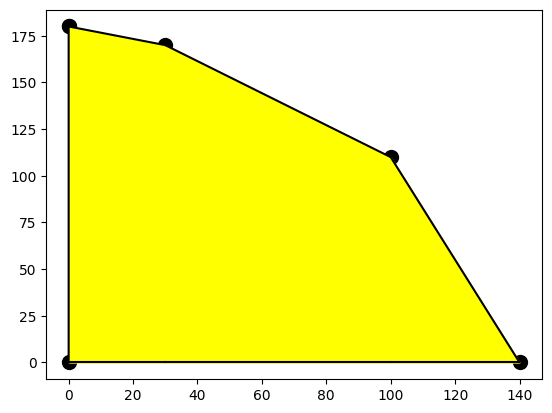

In [ ]:
import matplotlib.pyplot as plt

x1= np.arange(0,30,.1)
x2= np.arange(30,100,.1)
x3 = np.arange(100,140,.1)


y1 = (540-1*x1)/3
y2 = (1370-6*x2)/7
y3 = (1540-11*x3)/4

plt.plot(x1,y1, color = "black")
plt.plot(x2,y2, color = "black")
plt.plot(x3,y3, color = "black")
plt.plot(x1,np.zeros(300),x2,np.zeros(700),x3,np.zeros(400), color = "black")
plt.plot(np.zeros(1800),np.arange(0,180,.1),color = "black")
plt.scatter(30,170, s = 100, color = "black")
plt.scatter(100,110, s = 100, color = "black")
plt.scatter(0,180, s = 100, color = "black")
plt.scatter(140,0, s = 100, color = "black")
plt.scatter(0,180, s = 100, color = "black")
plt.scatter(0,0, s = 100, color = "black")
plt.fill_between(x1,0,y1, color = "yellow")
plt.fill_between(x2,0,y2, color = "yellow")
plt.fill_between(x3,0,y3, color = "yellow")

>We should also note that there are corner points at the intersection of the vertical line $x = 0$ and the horizontal line $y=0$ including where those two lines intersect.  The $y$-intercept is found by solving for $y$ in the sewing equation when $x=0$.  The $x$-intercept is found by solving for $y$ in the fill equation when $y=0$.

> So the intern now knows that any point inside this region is what is possible in any given week!  Now we ask, how to maximize the profit?  Let's get an equation in terms of our set up!

$$
P= 3x+2y
$$

>We can pick some values for $P$ and see what happens.  

In [ ]:

plt.fill_between(x1,0,y1, color = "yellow")
plt.fill_between(x2,0,y2, color = "yellow")
plt.fill_between(x3,0,y3, color = "yellow")

plt.plot(x4,(210-3*x4)/2,linestyle = "dashed", label = "210")
plt.plot(x5,(300-3*x5)/2,linestyle = "dashed", label = "300")
plt.plot(x6,(390-3*x6)/2,linestyle = "dashed", label = "390")
plt.plot(x7,(480-3*x7)/2,linestyle = "dashed"x1= np.arange(0,30,.1)
x2= np.arange(30,100,.1)
x3 = np.arange(100,140,.1)
x4 = np.arange(0,70,.1)
x5 = np.arange(0,100,.1)
x6 = np.arange(0,130,.1)
x7 = np.arange(0,160,.1)

y1 = (540-1*x1)/3
y2 = (1370-6*x2)/7
y3 = (1540-11*x3)/4

plt.plot(x1,y1, color = "black")
plt.plot(x2,y2, color = "black")
plt.plot(x3,y3, color = "black")
plt.plot(x1,np.zeros(300),x2,np.zeros(700),x3,np.zeros(400), color = "black")
plt.plot(np.zeros(1800),np.arange(0,180,.1),color = "black")
plt.scatter(30,170, s = 100, color = "black")
plt.scatter(100,110, s = 100, color = "black")
plt.scatter(0,180, s = 100, color = "black")
plt.scatter(140,0, s = 100, color = "black")
plt.scatter(0,180, s = 100, color = "black")
plt.scatter(0,0, s = 100, color = "black"), label = "480")
plt.legend()
plt.show()


SyntaxError: invalid syntax. Perhaps you forgot a comma? (ipython-input-4178744225.py, line 8)

>We can see that for each of the $P$ values I selected there are some options for the day.  We should also notice that the corner point looks like it will produce a line that just touches it!

$$
P = 3x + 2y = 3\cdot100+2\cdot110 = 520
$$

>We'll graph that one and see!

In [ ]:
x1= np.arange(0,30,.1)
x2= np.arange(30,100,.1)
x3 = np.arange(100,140,.1)
x4 = np.arange(0,70,.1)
x5 = np.arange(0,100,.1)
x6 = np.arange(0,130,.1)
x7 = np.arange(0,160,.1)

y1 = (540-1*x1)/3
y2 = (1370-6*x2)/7
y3 = (1540-11*x3)/4

plt.plot(x1,y1, color = "black")
plt.plot(x2,y2, color = "black")
plt.plot(x3,y3, color = "black")
plt.plot(x1,np.zeros(300),x2,np.zeros(700),x3,np.zeros(400), color = "black")
plt.plot(np.zeros(1800),np.arange(0,180,.1),color = "black")
plt.scatter(30,170, s = 100, color = "black")
plt.scatter(100,110, s = 100, color = "black")
plt.scatter(0,180, s = 100, color = "black")
plt.scatter(140,0, s = 100, color = "black")
plt.scatter(0,180, s = 100, color = "black")
plt.scatter(0,0, s = 100, color = "black")
plt.fill_between(x1,0,y1, color = "yellow")
plt.fill_between(x2,0,y2, color = "yellow")
plt.fill_between(x3,0,y3, color = "yellow")


plt.plot(x7,(520-3*x7)/2,linestyle = "dashed", label = "520")
plt.legend()
plt.show()

>Triuphantly the intern tells the boss that we can maximize profits by making 100 large pillows and 110 small pillows!

### Theory

>The theory of linear programming can be stated in terms of the contraints and the objective function.  For a system of linear constraints and linear objective functions, the optimum values (minimum or maximum) will occur on the corner points of the feasible set described by the contraining function.

>If we consider that the feasible set of the constraining lines, it will create a polygon with sharp corners.  The linear objective function will cut through the polygon.  Any optimum point will be at one of the corners as the objective function just kisses the edge.

>Some care must be taken for unbounded feasible sets, an optimum solution may not be possible with the maximum (or minimum) going to infinity (negative infinity).

### Slack

>All of the inequalities in the constraint must be met but some will not be on their strict bounds.  This leaves **slack** in those inequalities.  Using our original problem as an example, we see that the sewing equation has some slack.  We could have done more sewing with the maximum profit $(100,110)$.
$$
x+3y = 100 +330 = 430\leq 540
$$
>The inequality is solved but 100 more hours of sewing are available each week.  This is slack in our solution.  

>The previous problem can actually be restated in terms of slack with the inequalities replaced with equalities.  
$$
\left\{
\begin{array}{l}
6x+7y+s_1 =  1370\\
x+3y +s_2 = 540\\
11x+4y+ s_3 =  1540
\end{array}
\right.
$$

>In the optimum solution $s_2=110$ and $s_1=s_3=0$.  For the inequalities to continue to hold we must ask that $s_1,s_2,s_3\geq 0$.

>Actually this insight gives us an alternative approach to solve linear programming problems.  If we restate the contraint in equation form with slack variables, we can formulate the theory as solutions to the system of equations with some of the slack variables set to zero.  Let's see that in action here.

>Since I have three equations, I'll be able to get a unique solution if I have three variables.  Currently I have 5, $x,y,s_1,s_2,s_3$.  If we set two of them equal to zero then we will be able to solve the system!



In [ ]:

x = np.arange(0,550,.1)

y1 = (540-1*x)/3
y2 = (1370-6*x)/7
y3 = (1540-11*x)/4

plt.plot(x,y1, color = "black")
plt.plot(x,y2, color = "black")
plt.plot(x,y3, color = "black")
plt.plot(x,np.zeros(5500), color = "black")
plt.plot(np.zeros(5500),x, color = "black")
plt.scatter(30,170, s = 100, color = "black")
plt.scatter(100,110, s = 100, color = "blue")
plt.scatter(140,0, s = 100, color = "yellow")
plt.scatter(0,180, s = 100, color = "orange")
plt.scatter(0,195.7, s = 100, color = "pink")
plt.xlim([-1,550])
plt.ylim([-1,400])


plt.show()

>1. $x=y=0$ This is the orgin in my graph, each slack is it's value and we achieve no profit, $P = \$0$
2. $x = s_1 = 0$ This is the *pink* point that falls outside of the feasible set.
3. $x= s_2 = 0$ This is the *orange* point falling inside the feasible set with a profit of $P = 180*2 = \$360$
4. $x = s_3 =0$
5. $y = s_1 = 0$
6. $y = s_2 = 0$
7. $y = s_3 = 0$
8. $s_1 = s_2 = 0$
9. $s_1 = s_3 = 0$ This was the optimal *blue* point
10. $s_2 = s_3 =0$ Intersection of lines outside the feasible set

>How do we know we got them all?  We had 5 variables $(x,y,s_1,s_2,s_3)$ and were trying to solve 3 equations.  So we were able to have $\binom 52 = \binom 53 =10$.  Let's write up a little program that evaluates each of these for us!

>Before we proceed, we should ask is there a quick way to tell if an intersection is outside of the feasible set.  Let's look at the *pink* point.  It has $x = s_1 = 0$  Let's ask python to solve that.

>I'll need to expand $A$ to include the slack variables.  Just remeber there will be a lot of zeros!  If I don't need $x$ and $s_1$, I'll only need the $y, s_2,$ and $s_3$ variables.

In [ ]:
A = np.array([[6,7,1,0,0],[1,3,0,1,0],[11,4,0,0,1]])

A[:,[1,3,4]]


>Now I solve it with the original $b$.

In [ ]:
np.linalg.solve(A[:,[1,3,4]],b)

>The issue is that the second slack variable $s_2$ is negative!  The slack is about how much extra we have, if we don't have extra but used too much, we'll get negatives and that is not allowed.  Let's write a little code to reassemble our variables.

In [ ]:
def buildFullList(indexref,solution):
  newlist =[]
  solutioncounter = 0
  for j in range(5):
    if j not in indexref:
      newlist.append(0)
    else:
      newlist.append(solution[solutioncounter])
      solutioncounter += 1
  return newlist

indexref = [1,3,4]
solution = np.linalg.solve(A[:,[1,3,4]],b)

allVariables = buildFullList(indexref,solution)

allVariables

>Now I want to check for negatives!

In [ ]:
def testForFeasible(list1):
  return all([i>=0 for i in list1])

testForFeasible(allVariables)

>We see this is not in the feasible set.  Let's do one more thing and compute the profit from this list.  I know this isn't possible but we'll need this function soon!

In [ ]:
def profit(list):
  return 3*list[0]+2*list[1]

profit(allVariables)

>Now I am going to put it all together and build a little table that looks at all 10 points in the order I presented them above.

In [ ]:
index = [[i,j,k] for i in range(5) for j in range(i+1,5) for k in range(j+1,5)] #which variables are not zero
d = {0:'large',1:'small',2:'slackFabric',3:'slackSewing',4:'slackfill'} #dictionary for keeping variable labels straight

X = []
for i in index:
  solution = [round(i,5) for i in np.linalg.solve(A[:,i],b)]
  list1 = buildFullList(i,solution)
  X.append([(d[i[0]],d[i[1]],d[i[2]]),solution,profit(list1),testForFeasible(list1)])

>I'll print the data in a nice table with headers.

In [ ]:
import pandas as pd

X = pd.DataFrame(X,columns = ['Variables Used','Solution','Profit','In Feasible'])
X

>Lastly I'll use some manipulation to print the maximum inside the feasible set. First I restrict to in the feasible set, then I'll search for the maximum entry of profit.

In [ ]:
XFeasible = X[X['In Feasible'] == True]

XFeasible

In [ ]:
XFeasible[XFeasible['Profit'].max()==XFeasible['Profit']]

>This gives us exactly the solution we found graphically but an algorithmic
way to find it!


### Schematic Diagram(Flowchart) of Simplex Method Algorithm

![SMImg4](https://raw.githubusercontent.com/nurfnick/Operations_Research/main/Drafts/Simplex%20Method/SMImg/SMImg4.png)


2.   Use the simplex method to solve the given
linear programming problem. (In each case the objective function
is to be maximized.)

>a)Objective function:
$$
z=5x_1+2x_2+8x_3
$$
Contraints:
$$
\begin{array}{l}
2x_1-4x_2+x_3\leq 42\\
2x_1+3x_2-x_3\leq 42\\
6x_1-x_2+3x_3\leq 42\\
x_1,x_2,x_3\geq 0\\
\end{array}
$$

-------

>b)Objective function:
$$
z=x_1+2x_2-x_4
$$
Contraints:
$$
\begin{array}{l}
x_1+2x_2+3x_3\leq 24\\
3x_2+7x_3+x_4\leq 42\\
x_1,x_2,x_3\geq 0\\
\end{array}
$$



-------

>c)Objective function:
$$
z=x_1+2x_2+x_3-x_4
$$
Contraints:
$$
\begin{array}{l}
x_1+x_2+3x_3_4x_4\leq 60\\
x_2+2x_3+5x_4\leq 50\\
2x_1+3x_2+6x_4\leq 72\\
x_1,x_2,x_3,x_4\geq 0\\
\end{array}
$$


In [ ]:
import numpy as np
from scipy.optimize import linprog

In [ ]:
max = [-1, -2, 0, 1, 0, 0]

lhs_eq= [[1, 2, 3, 0, 1, 0],
         [0, 3, 7, 1, 0, 1]]

rhs_eq = [[24],
          [42]]

In [ ]:
opt = linprog(c=max, A_ub=lhs_eq, b_ub=rhs_eq, bounds=None, method="revised simplex")


In [ ]:
opt

In [ ]:
-opt.fun


#References

>1.   Moyer, Todd O. “The Simplex Method for Systems of Linear Inequalities.” Ohio Journal of School Mathematics, https://library.osu.edu/ojs/index.php/OJSM/article/view/5302/4540.

>2.   Linear Inequalities.” Ohio Journal of School Mathematics, https://library.osu.edu/ojs/index.php/OJSM/article/view/5302/4540.

>3.   Carreira-Perpiñán, Miguel Á. "Simplex Method." From ***MathWorld***--A Wolfram Web Resource, created by Eric W. Weisstein. https://mathworld.wolfram.com/SimplexMethod.html

>4.   Coutinho, Demétrios & Xavier-de-Souza, Samuel. (2013). Multicore Scalability and Efficiency Analysis of the standard simplex algorithm.


## Problems to solve



1.   write the simplex tableau for the given linear programming problem. You do not need to solve the problem. (In each
case the objective function is to be maximized.)

>a)Objective function:
$$
z=x_1+2x_2
$$
Contraints:
$$
\begin{array}{l}
2x_1+x_2\leq 8\\
x_1+x_2-2x_3\leq 5\\
x_1,x_2\geq 5\\
\end{array}
$$

---------

>b)Objective function:
$$
z=2x_1+3x_2+4x_3
$$
Contraints:
$$
\begin{array}{l}
x_1+2x_2\leq 12\\
x_1+x_3\leq 8\\
x_1,x_2,x_3\geq 0\\
\end{array}
$$

-----

>c)Objective function:
$$
z=6x_1-9x_2
$$
Contraints:
$$
\begin{array}{l}
2x_1-3x_2\leq 6\\
x_1+x_2\leq 20\\
x_1,x_2\geq 0\\
\end{array}
$$




3.  A grower has 50 acres of land for which she plans to raise
three crops. It costs USD200 to produce an acre of carrots and
the profit is USD60 per acre. It costs USD80 to produce an acre of
celery and the profit is USD20 per acre. Finally, it costs USD140 to
produce an acre of lettuce and the profit is USD30 per acre. Use
the simplex method to find the number of acres of each crop
she should plant in order to maximize her profit. Assume that
her cost cannot exceed USD10,000.

------

4.  A fruit juice company makes two special drinks by blending
apple and pineapple juices. The first drink uses 30% apple
juice and 70% pineapple, while the second drink uses 60%
apple and 40% pineapple. There are 1000 liters of apple and
1500 liters of pineapple juice available. If the profit for the
first drink is USD0.60 per liter and that for the second drink is
USD0.50, use the simplex method to find the number of liters of
each drink that should be produced in order to maximize the
profit

-------

5.  A manufacturer produces three models of bicycles. The time
(in hours) required for assembling, painting, and packaging
each model is as follows.

||Model A|Model B|Model C|
|:------:|:------:|:------:|:----:|
|Assembling |2     |2.5     |3   |
|Painting |1.5     |2     |1   |
|packaging| 1|0.75|1.25|

>The total time available for assembling, painting, and packaging is 4006 hours, 2495 hours and 1500 hours, respectively. The profit per unit for each model is USD45 (Model A), USD50 (Model B), and USD55 (Model C). How many of each type
should be produced to obtain a maximum profit?






## Project Idea

>**Linear Program** is a model used to achieve the best outcome given a maximum or minimum equation with its linear constraints.


>**Optimal solution** of a maximization linear programming model are the values assigned to the variables in the objective function to give the largest zeta value.  The optimal solution would exist on the corner points of the graph of the entire model.

>**Pivot variable** is used in row operations to identify which variable will become the unit value and is a key factor in the conversion of the unit value.

### Authors

>Principal authors of this chapter were:

1.   Gulsan Rai
2.   Chiran Rayamajhi